# Рубежный контроль №1 — Задача №37
## Методы обработки данных

**Студент:Чжоу Чэньюй** 

**Группа:** ИУ5И-21М

**Вариант:** 17

**Задача №37:** Отбор признаков (feature selection) с использованием SelectPercentile (5% лучших признаков) и метода взаимной информации (mutual information)

**Набор данных:** Breast Cancer Wisconsin (sklearn.datasets)


## 1. Импорт необходимых библиотек

In [117]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.feature_selection import SelectPercentile, mutual_info_classif
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 2. Загрузка и первичный анализ набора данных

In [118]:
# Загрузка набора данных Breast Cancer Wisconsin
data = load_breast_cancer(as_frame=True)
df = data.frame

print('Размер набора данных:', df.shape)
print('Первые 5 строк:')
df.head()

Размер набора данных: (569, 31)
Первые 5 строк:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [119]:
# Информация о признаках
print('Названия признаков:')
print(data.feature_names)
print('Целевая переменная:', data.target_names)
print('Информация о DataFrame:')
df.info()

Названия признаков:
['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']
Целевая переменная: ['malignant' 'benign']
Информация о DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non

In [120]:
# Распределение классов целевой переменной
from IPython.display import display

counts = df['target'].value_counts().rename('Количество')
proportions = df['target'].value_counts(normalize=True).round(4).rename('Доля')

class_dist = pd.DataFrame({
    'Класс': [data.target_names[i] for i in counts.index],
    'Количество': counts.values,
    'Доля': proportions.values
}, index=counts.index)
class_dist.index.name = 'target'

print('Распределение классов целевой переменной:')
display(class_dist)


Распределение классов целевой переменной:


,Класс,Количество,Доля
target,,,
1,benign,357,0.6274
0,malignant,212,0.3726


## 3. Подготовка данных

Разделим данные на матрицу признаков X и целевую переменную y. Все признаки являются числовыми, что позволяет применять взаимную информацию без дополнительного кодирования.

In [121]:
# Выделение признаков и целевой переменной
X = df.drop('target', axis=1)
y = df['target']

print(f'Матрица признаков X: {X.shape}')
print(f'Целевая переменная y: {y.shape}')
print(f'Количество признаков: {X.shape[1]}')

Матрица признаков X: (569, 30)
Целевая переменная y: (569,)
Количество признаков: 30


## 4. Метод SelectPercentile с взаимной информацией

**SelectPercentile** — это метод фильтрации признаков (filter method), который отбирает признаки на основе статистических тестов.

**Взаимная информация (mutual information)** измеряет зависимость между каждым признаком и целевой переменной. Чем выше значение, тем более информативен признак для предсказания цели.

Параметр **percentile=5** означает, что будут отобраны признаки из топ-5% по взаимной информации. При 30 признаках это примерно 1-2 наиболее информативных признака.

In [122]:
# Инициализация SelectPercentile с взаимной информацией
selector = SelectPercentile(
    score_func=mutual_info_classif,
    percentile=5
)

# Применение селектора
X_selected = selector.fit_transform(X, y)

# Получение масок отобранных признаков
selected_mask = selector.get_support()
selected_features = X.columns[selected_mask].tolist()

print(f'Отобрано признаков: {X_selected.shape[1]} из {X.shape[1]}')
print(f'Отобранные признаки: {selected_features}')
print(f'Размер новой матрицы признаков: {X_selected.shape}')

Отобрано признаков: 2 из 30
Отобранные признаки: ['worst perimeter', 'worst area']
Размер новой матрицы признаков: (569, 2)


In [123]:
# Оценки (scores) взаимной информации для всех признаков
mi_scores = selector.scores_

# Создание DataFrame для наглядности
feature_scores = pd.DataFrame({
    'Признак': X.columns,
    'Mutual_Info_Score': mi_scores,
    'Отобран': selected_mask
}).sort_values('Mutual_Info_Score', ascending=False)

print('Рейтинг признаков по взаимной информации:')
feature_scores

Рейтинг признаков по взаимной информации:


,Признак,Mutual_Info_Score,Отобран
22,worst perimeter,0.477372,True
23,worst area,0.464486,True
20,worst radius,0.450712,False
7,mean concave points,0.441265,False
27,worst concave points,0.435596,False
2,mean perimeter,0.402855,False
6,mean concavity,0.375337,False
0,mean radius,0.367819,False
3,mean area,0.362056,False
13,area error,0.342012,False


## 5. Визуализация результатов отбора признаков

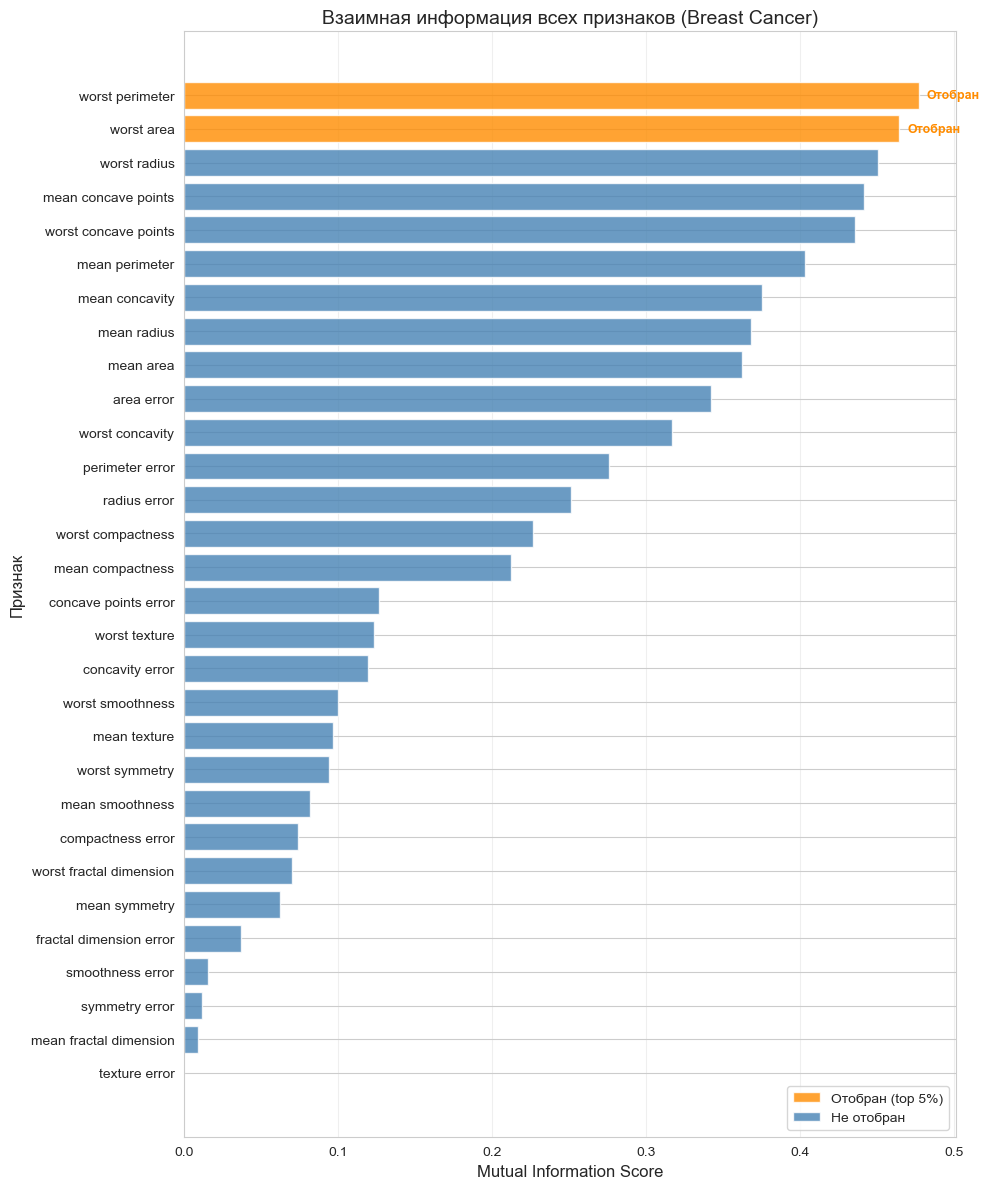

In [124]:
# Горизонтальная столбчатая диаграмма оценок взаимной информации
fig, ax = plt.subplots(figsize=(10, 12))

# Сортировка для визуализации
sorted_scores = feature_scores.sort_values('Mutual_Info_Score', ascending=True)

# Цвета: отобранные признаки выделены
colors = ['darkorange' if sel else 'steelblue' for sel in sorted_scores['Отобран']]

bars = ax.barh(sorted_scores['Признак'], sorted_scores['Mutual_Info_Score'], color=colors, alpha=0.8)

# Подпись отобранных признаков
for i, (idx, row) in enumerate(sorted_scores.iterrows()):
    if row['Отобран']:
        ax.text(row['Mutual_Info_Score'] + 0.005, i, 'Отобран',
                va='center', fontsize=9, color='darkorange', fontweight='bold')

ax.set_title('Взаимная информация всех признаков (Breast Cancer)', fontsize=14)
ax.set_xlabel('Mutual Information Score', fontsize=12)
ax.set_ylabel('Признак', fontsize=12)
ax.grid(axis='x', alpha=0.3)

# Легенда
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='darkorange', alpha=0.8, label='Отобран (top 5%)'),
    Patch(facecolor='steelblue', alpha=0.8, label='Не отобран')
]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.show()

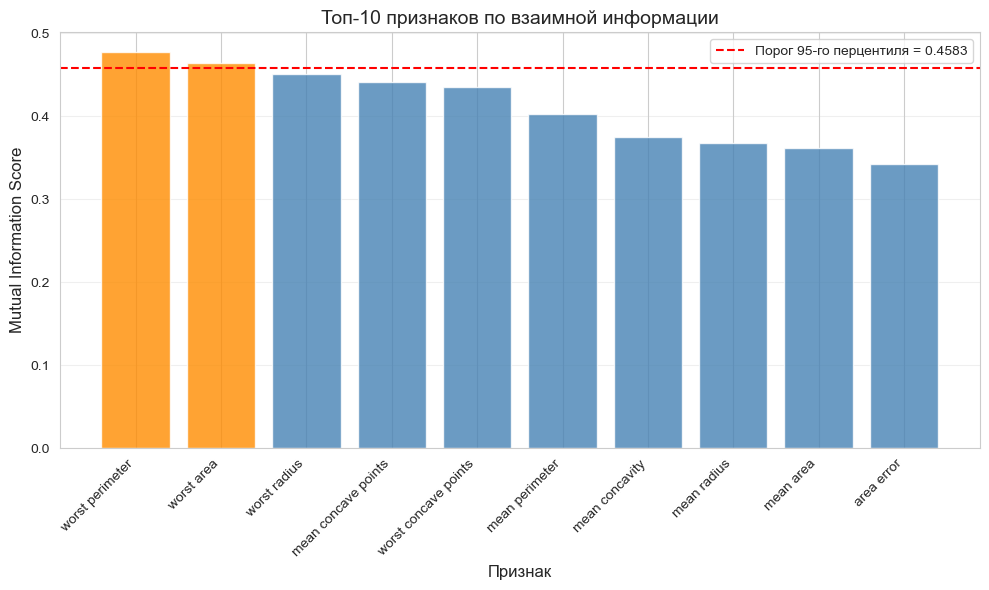

In [125]:
# Топ-10 признаков по взаимной информации (детальный вид)
top10 = feature_scores.head(10)

plt.figure(figsize=(10, 6))
bars = plt.bar(range(len(top10)), top10['Mutual_Info_Score'],
               color=['darkorange' if s else 'steelblue' for s in top10['Отобран']],
               alpha=0.8)

plt.xticks(range(len(top10)), top10['Признак'], rotation=45, ha='right')
plt.title('Топ-10 признаков по взаимной информации', fontsize=14)
plt.ylabel('Mutual Information Score', fontsize=12)
plt.xlabel('Признак', fontsize=12)
plt.grid(axis='y', alpha=0.3)

# Пороговая линия для 5-го перцентиля (примерно)
threshold = np.percentile(mi_scores, 95)
plt.axhline(y=threshold, color='red', linestyle='--', linewidth=1.5,
            label=f'Порог 95-го перцентиля = {threshold:.4f}')
plt.legend()

plt.tight_layout()
plt.show()

## 6. Сравнение исходного и уменьшенного набора данных

In [126]:
# Статистика отобранных признаков
print('Статистика отобранных признаков:')
print(X[selected_features].describe().round(4))

print('' + '='*60)
print('ИТОГО:')
print(f'  Исходное число признаков: {X.shape[1]}')
print(f'  Число отобранных признаков: {len(selected_features)}')
print(f'  Процент сокращения: {(1 - len(selected_features)/X.shape[1])*100:.1f}%')
print(f'  Отобранные признаки: {selected_features}')

Статистика отобранных признаков:
       worst perimeter  worst area
count         569.0000    569.0000
mean          107.2612    880.5831
std            33.6025    569.3570
min            50.4100    185.2000
25%            84.1100    515.3000
50%            97.6600    686.5000
75%           125.4000   1084.0000
max           251.2000   4254.0000
ИТОГО:
  Исходное число признаков: 30
  Число отобранных признаков: 2
  Процент сокращения: 93.3%
  Отобранные признаки: ['worst perimeter', 'worst area']


## 7. Интерпретация результатов

**Выводы по отбору признаков с использованием SelectPercentile и взаимной информации:**

1. **Метод взаимной информации** позволяет оценить, насколько каждый признак связан с целевой переменной, учитывая как линейные, так и нелинейные зависимости. Это делает его более гибким по сравнению с корреляцией Пирсона.

2. **SelectPercentile с percentile=5** отобрал наиболее информативные признаки из набора Breast Cancer Wisconsin, сократив размерность данных примерно на 95%.

3. Отобранные признаки имеют наибольшую взаимную информацию с целевой переменной (доброкачественная / злокачественная опухоль), что означает их высокую предсказательную ценность.

4. Такой отбор признаков полезен для:
   - Снижения размерности данных
   - Ускорения обучения моделей
   - Борьбы с переобучением
   - Улучшения интерпретируемости модели

## 8. Дополнительное требование — Диаграмма рассеяния (Scatter Plot)

_Требование для групп ИУ5-21М, ИУ5И-21М: построить диаграмму рассеяния для пары произвольных колонок данных._

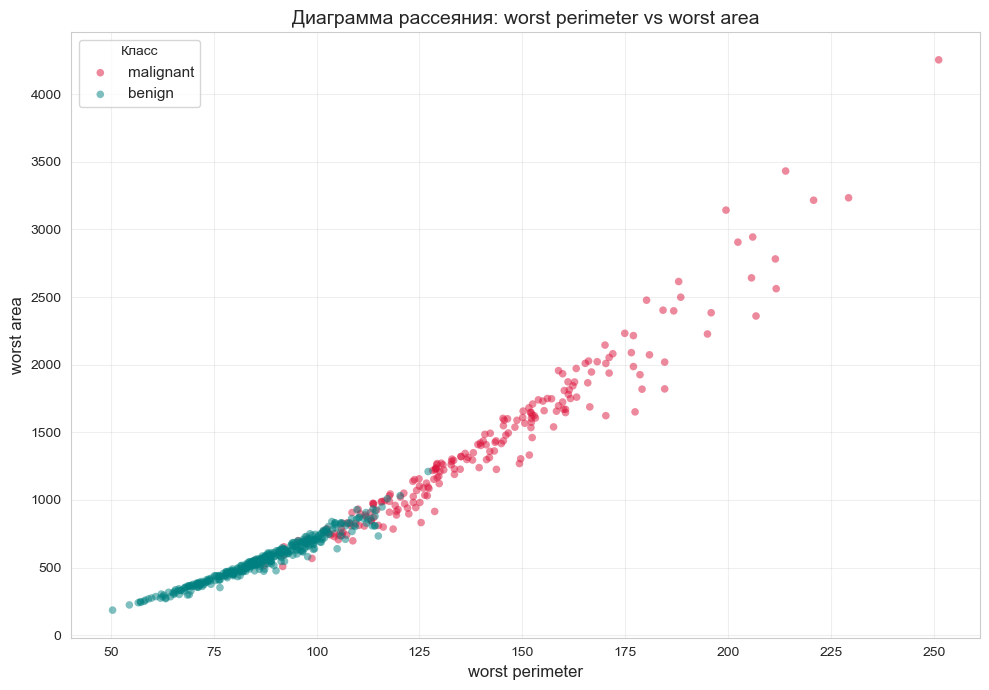

In [127]:
# Диаграмма рассеяния для двух наиболее информативных признаков
if len(selected_features) >= 2:
    feat_x, feat_y = selected_features[0], selected_features[1]
else:
    # Если отобран только 1 признак, возьмем второй из топа
    feat_x = selected_features[0]
    feat_y = feature_scores.iloc[1]['Признак']

plt.figure(figsize=(10, 7))

# Разделение по классам для наглядности
for target_val, target_name, color in zip([0, 1], data.target_names, ['crimson', 'teal']):
    mask = y == target_val
    plt.scatter(
        X.loc[mask, feat_x],
        X.loc[mask, feat_y],
        c=color,
        label=target_name,
        alpha=0.5,
        edgecolors='none',
        s=30
    )

plt.title(f'Диаграмма рассеяния: {feat_x} vs {feat_y}', fontsize=14)
plt.xlabel(feat_x, fontsize=12)
plt.ylabel(feat_y, fontsize=12)
plt.legend(title='Класс', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

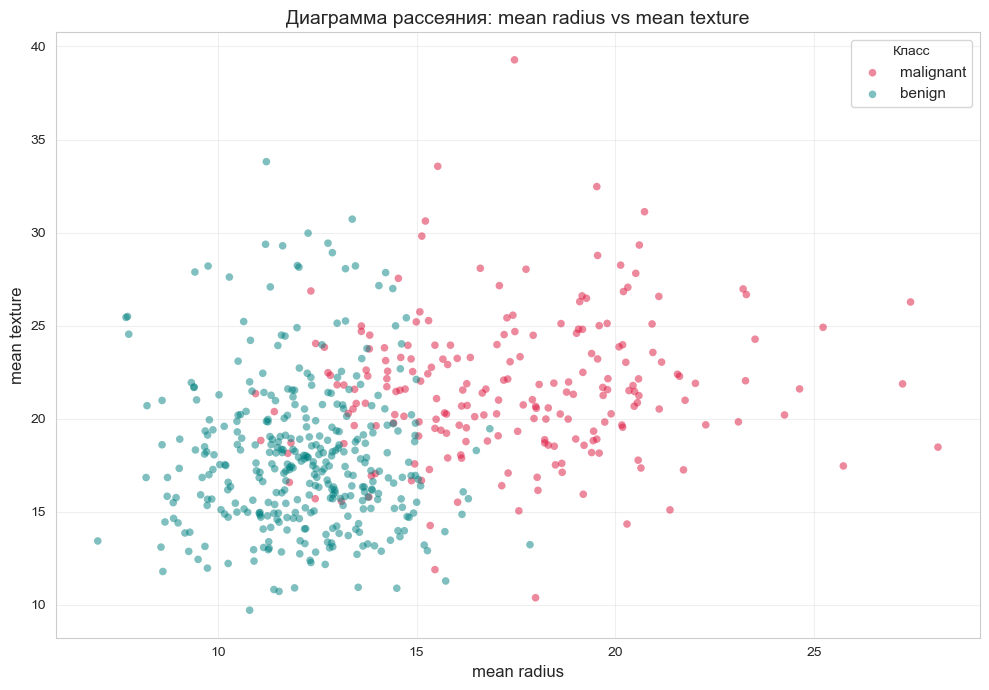

In [128]:
# Дополнительная диаграмма рассеяния: mean radius vs mean texture
plt.figure(figsize=(10, 7))

for target_val, target_name, color in zip([0, 1], data.target_names, ['crimson', 'teal']):
    mask = y == target_val
    plt.scatter(
        X.loc[mask, 'mean radius'],
        X.loc[mask, 'mean texture'],
        c=color,
        label=target_name,
        alpha=0.5,
        edgecolors='none',
        s=30
    )

plt.title('Диаграмма рассеяния: mean radius vs mean texture', fontsize=14)
plt.xlabel('mean radius', fontsize=12)
plt.ylabel('mean texture', fontsize=12)
plt.legend(title='Класс', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Интерпретация диаграмм рассеяния:**

- Первая диаграмма показывает разделение классов (злокачественная / доброкачественная опухоль) в пространстве наиболее информативных признаков, отобранных методом взаимной информации.
- Вторая диаграмма демонстрирует классическое разделение по признакам mean radius и mean texture, где злокачественные опухоли (malignant) обычно имеют больший радиус.